In [2]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Annotated, List

import random

import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

from geneticengine.grammar.metahandlers.ints import IntRange
from geneticengine.grammar import extract_grammar
from geneticengine.grammar.decorators import weight
from geneticengine.problems import SingleObjectiveProblem, MultiObjectiveProblem
from geneticengine.random.sources import NativeRandomSource
from geneticengine.algorithms.gp.gp import GeneticProgramming
from geneticengine.evaluation.budget import TimeBudget, EvaluationBudget
from geneticengine.representations.tree.initializations import MaxDepthDecider, FullDecider, ProgressivelyTerminalDecider, PositionIndependentGrowDecider
from geneticengine.representations.tree.operators import GrowInitializer, PositionIndependentGrowInitializer, FullInitializer, RampedHalfAndHalfInitializer
from geneticengine.algorithms.gp.operators.initializers import HalfAndHalfInitializer, StandardInitializer
from geneticengine.representations.tree.treebased import TreeBasedRepresentation
from geneticengine.representations.grammatical_evolution.structured_ge import StructuredGrammaticalEvolutionRepresentation
from geneticengine.evaluation.recorder import CSVSearchRecorder
from geneticengine.evaluation.tracker import ProgressTracker
from geneticengine.evaluation.parallel import ParallelEvaluator

from geneticengine.algorithms.gp.operators.combinators import ParallelStep, SequenceStep
from geneticengine.algorithms.gp.operators.crossover import GenericCrossoverStep
from geneticengine.algorithms.gp.operators.elitism import ElitismStep
from geneticengine.algorithms.gp.operators.mutation import GenericMutationStep
from geneticengine.algorithms.gp.operators.novelty import NoveltyStep
from geneticengine.algorithms.gp.operators.selection import LexicaseSelection, TournamentSelection

from geneticengine.solutions.individual import Individual, PhenotypicIndividual
from geneticengine.algorithms.gp.structure import GeneticStep
from geneticengine.problems import Problem
from geneticengine.random.sources import RandomSource
from geneticengine.representations.api import RepresentationWithCrossover, Representation
from geneticengine.evaluation import Evaluator
from typing import Iterator, Any, TypeVar

from sklearn.datasets import load_breast_cancer

import pandas as pd

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE, mutual_info_classif

import time

import seaborn as sns
import matplotlib.pyplot as plt

import os     

from functools import lru_cache

import lightgbm as lgb

from sklearn.model_selection import StratifiedKFold

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
model_used = lgb.LGBMClassifier(n_estimators=50, max_depth=7, learning_rate=0.03, num_leaves=10, boosting_type='gbdt', random_state=42, n_jobs=-1, verbose=-1)
target_fpr_value = 0.05

### Functions and Data Preprocessing

In [5]:
for attemp in range(3):
    try:
        if os.path.exists('Base.csv'):
            df_orig = pd.read_csv('Base.csv')
            print("Dataset loaded successfully")
            break
        else:
            import kagglehub
            import shutil
            path = kagglehub.dataset_download("sgpjesus/bank-account-fraud-dataset-neurips-2022")
            csv_path = os.path.join(path, "Base.csv")
            shutil.copy(csv_path, "Base.csv")
            df_orig = pd.read_csv('Base.csv')
            print("Dataset downloaded and loaded successfully")
            break
    except Exception as e:
        print(f"Attempting again to download dataset due to error: {e}")
        if attemp < 2:
            time.sleep(5)
        else:
            raise e

Dataset loaded successfully


In [6]:
df_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [7]:
df_orig.head(2)

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0


In [8]:
#save the df with the values until month 6
df = df_orig
#train until month 6 and test after month 6
train_df = df[df['month'] < 3].sample(frac=1, random_state=42)
val_df = df[df['month'] == 3].sample(frac=1, random_state=42)
prune_df = df[(df['month'] == 4) | (df['month'] == 5)].sample(frac=1, random_state=42)
test_df = df[df['month'] >= 6].sample(frac=1, random_state=42)

train_df.drop('month', axis=1, inplace=True)
test_df.drop('month', axis=1, inplace=True)
val_df.drop('month', axis=1, inplace=True)
prune_df.drop('month', axis=1, inplace=True)

#split into X and y
X_train = train_df.drop('fraud_bool', axis=1)
y_train = train_df['fraud_bool']
X_val = val_df.drop('fraud_bool', axis=1)
y_val = val_df['fraud_bool']
X_prune = prune_df.drop('fraud_bool', axis=1)
y_prune = prune_df['fraud_bool']
X_test = test_df.drop('fraud_bool', axis=1)
y_test = test_df['fraud_bool']
print(len(df))

1000000


In [9]:
# X = df.drop(['fraud_bool'], axis=1)
# y = df['fraud_bool']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [10]:
categorical_features = [
    "payment_type",
    "employment_status",
    "housing_status",
    "source",
    "device_os",
]


encoders = {}
for feat in categorical_features:
    encoder = LabelEncoder()
    X_train[feat] = encoder.fit_transform(X_train[feat])
    X_val[feat] = encoder.transform(X_val[feat])
    X_prune[feat] = encoder.transform(X_prune[feat])
    X_test[feat] = encoder.transform(X_test[feat])
    encoders[feat] = encoder

categorical_indices = [X_train.columns.get_loc(feat) for feat in categorical_features]

In [11]:
print(y_train.value_counts(),y_val.value_counts(), y_prune.value_counts(), y_test.value_counts())

fraud_bool
0    393143
1      3896
Name: count, dtype: int64 fraud_bool
0    149544
1      1392
Name: count, dtype: int64 fraud_bool
0    244151
1      2863
Name: count, dtype: int64 fraud_bool
0    202133
1      2878
Name: count, dtype: int64


### Baseline Model

In [12]:
feature_names = X_train.columns.tolist()
n_features = len(feature_names)

In [13]:
n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_results = []

for fold , (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model_fold = lgb.LGBMClassifier(n_estimators=50, max_depth=7, learning_rate=0.03, num_leaves=10, boosting_type='gbdt', random_state=42, n_jobs=-1, verbose=-1, scale_pos_weight= (y_train_fold==0).sum() / (y_train_fold==1).sum())
    model_fold.fit(X_train_fold, y_train_fold, categorical_feature=categorical_indices)

    val_probs_fold = model_fold.predict_proba(X_val_fold)[:,1]
    fpr, tpr, thresholds_fold = roc_curve(y_val_fold, val_probs_fold)
    target_fpr = target_fpr_value
    tpr_at_fpr = 0.0

    if np.any(fpr <= target_fpr):
        valid_indices = np.where(fpr <= target_fpr)[0]
        best_index = valid_indices[np.argmax(tpr[valid_indices])]
        tpr_at_fpr = tpr[best_index]
    fold_results.append(tpr_at_fpr)
    print(f"Fold {fold} - TPR at FPR {target_fpr_value}: {tpr_at_fpr}")

baseline_tpr_at_fpr = np.mean(fold_results)
    
print(f"Validation TPR: {baseline_tpr_at_fpr}")

Fold 1 - TPR at FPR 0.05: 0.47344110854503463
Fold 2 - TPR at FPR 0.05: 0.4445300462249615
Fold 3 - TPR at FPR 0.05: 0.44803695150115475
Validation TPR: 0.455336035423717


### Grammar

In [14]:
@dataclass
class Value(ABC):
    def evaluate(self):
        pass

class Scalar(ABC):
    pass

In [15]:
@weight(1.2)
@dataclass #Scalar Features (1)
class ScalarVar(Scalar): 
    index: Annotated[int, IntRange(0,n_features-1)]

    def evaluate(self, X_np):
        return X_np[:, self.index]
    
    def __str__(self):
        return feature_names[self.index]

In [16]:
#scalar -> scalar
@weight(0.2)
@dataclass 
class Add(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np):
        return self.left.evaluate(X_np) + self.right.evaluate(X_np)
    
    def __str__(self):
        return f"({self.left} + {self.right})"

@weight(0.2)
@dataclass
class Subtract(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np):
        return (self.left.evaluate(X_np)) - (self.right.evaluate(X_np))
    
    def __str__(self):
        return f"({self.left} - {self.right})"

@weight(0.2)
@dataclass
class Multiply(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np):
        return self.left.evaluate(X_np) * self.right.evaluate(X_np)
    
    def __str__(self):
        return f"({self.left} * {self.right})"

@weight(0.2)
@dataclass
class Divide(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np):
        denom = self.right.evaluate(X_np)
        denom = np.where(denom == 0, 1e-6, denom)  # Avoid division by zero
        return self.left.evaluate(X_np) / denom
    
    def __str__(self):
        return f"({self.left} / {self.right})"
    
@weight(0.2)
@dataclass
class Sqrt(Scalar):
    value: Scalar

    def evaluate(self, X_np):
        val = self.value.evaluate(X_np)
        val = np.asarray(val)
        val = np.clip(val, a_min=0.0, a_max=None)
        return np.sqrt(val)

    def __str__(self):
        return f"sqrt({self.value})"
    
@weight(0.2)
@dataclass
class Log(Scalar):
    value: Scalar

    def evaluate(self, X_np):
        val = self.value.evaluate(X_np)
        val = np.asarray(val)
        val = np.where(val <= 0, 1e-6, val)
        return np.log(val)
    
    def __str__(self):
        return f"log({self.value})"

In [17]:
grammar = extract_grammar([Add, Subtract, Multiply, Divide, Sqrt, Log, ScalarVar], Scalar)
print(f"Grammar: {repr(grammar)}")

Grammar: Grammar<Starting=Scalar,Productions={
Scalar -> Add(right: Scalar, left: Scalar)<0.08>|
	Subtract(right: Scalar, left: Scalar)<0.08>|
	Multiply(right: Scalar, left: Scalar)<0.08>|
	Divide(right: Scalar, left: Scalar)<0.08>|
	Sqrt(value: Scalar)<0.08>|
	Log(value: Scalar)<0.08>|
	ScalarVar(index: Annotated[int])<0.50>
}


### Fitness and GP

In [18]:
ARCHIVE_T_DF_TEMP = X_train.copy()

ARCHIVE_TEMP : list[Individual] = []
ARCHIVE_IND_DICT: dict[str, Individual] = {}
ARCHIVE_IND = []
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()
X_val_np = X_val.to_numpy()
y_val_np = y_val.to_numpy()
X_prune_np = X_prune.to_numpy()
y_prune_np = y_prune.to_numpy()
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

In [19]:
def fitness_function(individual: Scalar): #individual -> expression
    
    if str(individual) in X_train.columns:
        return [0.0, 0.0, 1000.0, 1000.0]
    
    start = time.perf_counter()
    new_feature_train = individual.evaluate(X_train_np)
    if new_feature_train.ndim == 0:
        new_feature_train = np.full(X_train_np.shape[0], new_feature_train)
    X_augmented_train = np.c_[X_train_np, new_feature_train]

    new_feature_val = individual.evaluate(X_val_np)
    if new_feature_val.ndim == 0:
        new_feature_val = np.full(X_val_np.shape[0], new_feature_val)
    X_augmented_val = np.c_[X_val_np, new_feature_val]
        
    model_fold = lgb.LGBMClassifier(n_estimators=50, max_depth=7, learning_rate=0.03, num_leaves=10, boosting_type='gbdt', random_state=42, n_jobs=-1, verbose=-1, scale_pos_weight= (y_train==0).sum() / (y_train==1).sum())

    model_fold.fit(X_augmented_train, y_train_np, categorical_feature=categorical_indices)
        
    val_probs = model_fold.predict_proba(X_augmented_val)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_val_np, val_probs)

    target_fpr = target_fpr_value

    tpr_at_fpr = 0.0

    if np.any(fpr <= target_fpr):
        valid_indices = np.where(fpr <= target_fpr)[0]
        best_index = valid_indices[np.argmax(tpr[valid_indices])]
        tpr_at_fpr = tpr[best_index]

    tpr_diff = tpr_at_fpr - baseline_tpr_at_fpr
        
    features, num_operations = analyse_complexity(individual)

    end = time.perf_counter()
    elapsed = end - start
    return [tpr_at_fpr, tpr_diff, num_operations, elapsed]



In [20]:
def analyse_complexity(individual: Scalar):
    if isinstance(individual, ScalarVar):
        return {individual.index}, 0 #unique feature
    
    total_features = set()
    total_operations = 1
    if hasattr(individual, 'left') and hasattr(individual, 'right'):
        left_features, left_operations = analyse_complexity(individual.left)
        right_features, right_operations = analyse_complexity(individual.right)
        total_features.update(left_features)
        total_features.update(right_features)
        total_operations += left_operations + right_operations
    elif hasattr(individual, 'value'):
        value_features, value_operations = analyse_complexity(individual.value)
        total_features.update(value_features)
        total_operations += value_operations
    return total_features, total_operations


In [21]:
from sklearn.feature_selection import RFE

import pickle

class ArchiveStep(GeneticStep):
    def iterate(
        self,
        problem: Problem,
        evaluator: Evaluator,
        representation: Representation,
        random: RandomSource,
        population: Iterator[PhenotypicIndividual],
        target_size: int,
        generation: int,
    ) -> Iterator[PhenotypicIndividual]:
        global ARCHIVE_TEMP, baseline_tpr_at_fpr, ARCHIVE_T_DF_TEMP, ARCHIVE_IND_DICT, ARCHIVE_IND
        
        for i, individual in enumerate(population):
            if str(individual.get_phenotype()) in ARCHIVE_T_DF_TEMP.columns:
                yield individual
                continue
            if individual.get_fitness(problem).fitness_components[0] > baseline_tpr_at_fpr:
                feature_new = individual.get_phenotype().evaluate(X_train_np)
                if feature_new.ndim == 0:
                    feature_new = np.full(X_train_np.shape[0], feature_new)
                ARCHIVE_T_DF_TEMP[str(individual.get_phenotype())] = feature_new
                ARCHIVE_IND_DICT[str(individual.get_phenotype())] = individual
                ARCHIVE_TEMP.append(individual)
            yield individual
        
        if ARCHIVE_TEMP:
            print(f"Archive Size: {len(ARCHIVE_TEMP)}")

        if ARCHIVE_TEMP and generation % 15 == 0:
            print(f"Archive Size at pruning: {len(ARCHIVE_TEMP)}")
            
            num_features = len(ARCHIVE_T_DF_TEMP.columns)
            original_cols = set(X_train.columns)
            num_original = len(original_cols)
            num_new_features = sum(1 for col in ARCHIVE_T_DF_TEMP.columns if col not in original_cols)
            
            n_features_to_select = 40

            if num_features <= n_features_to_select:
                print(f"Low number of features")
                ARCHIVE_TEMP = []
                return
            
            print(f"Selecting {n_features_to_select}")
            
            estimator = lgb.LGBMClassifier(
                n_estimators=50, 
                max_depth=7, 
                learning_rate=0.03, 
                num_leaves=10, 
                boosting_type='gbdt', 
                random_state=42, 
                n_jobs=-1, 
                verbose=-1,
                scale_pos_weight=(y_train_np==0).sum() / (y_train_np==1).sum()
            )
            
            rfe = RFE(
                estimator=estimator,
                n_features_to_select=n_features_to_select,
                step=max(1, (num_features - n_features_to_select) // 15), #delete features in 15 steps 
                verbose=0
            )
            
            rfe.fit(ARCHIVE_T_DF_TEMP.to_numpy(), y_train_np)
            
            selected_mask = rfe.support_
            feature_cols = ARCHIVE_T_DF_TEMP.columns.tolist()
            features_to_keep = [col for col, selected in zip(feature_cols, selected_mask) if selected]

            if len(features_to_keep) < n_features_to_select:
                print(f"Selected less features than expected.")

            ARCHIVE_T_DF_TEMP = ARCHIVE_T_DF_TEMP[features_to_keep]
            
            ARCHIVE_IND = [ARCHIVE_IND_DICT[col] for col in features_to_keep 
                          if col not in original_cols and col in ARCHIVE_IND_DICT]
            ARCHIVE_IND_DICT = {col: ARCHIVE_IND_DICT[col] for col in features_to_keep 
                               if col in ARCHIVE_IND_DICT}
            
            X_prune_archive = pd.DataFrame(index=X_prune.index)
            for col in features_to_keep:
                if col in X_prune.columns:
                    X_prune_archive[col] = X_prune[col]
                elif col in ARCHIVE_IND_DICT:
                    prune_feature = ARCHIVE_IND_DICT[col].get_phenotype().evaluate(X_prune_np)
                    if prune_feature.ndim == 0:
                        prune_feature = np.full(len(X_prune), prune_feature)
                    X_prune_archive[col] = prune_feature
            
            X_train_archive = ARCHIVE_T_DF_TEMP.to_numpy()
            X_prune_archive_np = X_prune_archive.to_numpy()
            
            new_categorical_indices = [list(ARCHIVE_T_DF_TEMP.columns).index(name)
                                       for name in categorical_features
                                       if name in ARCHIVE_T_DF_TEMP.columns]
            
            model = lgb.LGBMClassifier(
                n_estimators=50, max_depth=7, learning_rate=0.03, 
                num_leaves=10, boosting_type='gbdt', random_state=42, 
                n_jobs=-1, verbose=-1, 
                scale_pos_weight=(y_train_np==0).sum() / (y_train_np==1).sum()
            )
            
            model.fit(X_train_archive, y_train_np, 
                     categorical_feature=new_categorical_indices if new_categorical_indices else None)
            probs = model.predict_proba(X_prune_archive_np)[:, 1]
            
            fpr, tpr, thresholds = roc_curve(y_prune_np, probs)

            tpr_at_fpr=0.0
            target_fpr = target_fpr_value
            if np.any(fpr <= target_fpr):
                valid_indices = np.where(fpr <= target_fpr)[0]
                best_index = valid_indices[np.argmax(tpr[valid_indices])]
                tpr_at_fpr = tpr[best_index]
            
            baseline_tpr_at_fpr = tpr_at_fpr

            print(f"Post-RFE Prune TPR at FPR {target_fpr}: {tpr_at_fpr:.4f}")

            os.makedirs("checkpoints", exist_ok=True)
            with open("checkpoints/archive.pkl", "wb") as f:
                pickle.dump({
                    'ARCHIVE_T_DF_TEMP': ARCHIVE_T_DF_TEMP,
                    'feature_expressions': {col: str(ARCHIVE_IND_DICT[col].get_phenotype()) 
                                           for col in ARCHIVE_IND_DICT.keys()},
                    'baseline_tpr_at_fpr': baseline_tpr_at_fpr,
                    'generation': generation
                }, f)
            
            ARCHIVE_TEMP = []

In [ ]:
def lexicase_step():
    return SequenceStep(
        ArchiveStep(),
        ParallelStep(
            [
                ElitismStep(),
                # NoveltyStep(),
                SequenceStep(
                    LexicaseSelection(epsilon=True),
                    # TournamentSelection(tournament_size=4),
                    GenericCrossoverStep(0.9),
                    GenericMutationStep(0.1),
                )
            ],
            # weights=[0.05, 0.05, 0.9]
            weights=[0.1, 0.9]
        ),
    )

prob = MultiObjectiveProblem(
    fitness_function=fitness_function,
    minimize=[False, False, True, True],
)
r = NativeRandomSource(123)
alg = GeneticProgramming(
    problem=prob,
    budget=TimeBudget(1200),
    population_size=50,
    representation=TreeBasedRepresentation(grammar, MaxDepthDecider(r, grammar, 5)),
    random=r,
    step=lexicase_step(),
    tracker=ProgressTracker(
        prob,
        recorders=[CSVSearchRecorder(
            csv_path='output.csv', 
            problem=prob, 
            fields={
                    "Eval Time": lambda t,i,p: i.get_fitness(p).fitness_components[3],
                    "TPR Test": lambda t,i,p: i.get_fitness(p).fitness_components[0],
                    "TPR Test Diff": lambda t,i,p: i.get_fitness(p).fitness_components[1],
                    "Expression": lambda t, i, p: i.get_phenotype(),
                    "Num Operations": lambda t,i,p: i.get_fitness(p).fitness_components[2],
                    'Generation': lambda t,i,p: i.metadata["generation"]
                    },
            only_record_best_individuals=False)]
    )
    
)

solutions = alg.search()

KeyboardInterrupt: 

In [ ]:
import pickle

with open("checkpoints/archive.pkl", "rb") as f:
    data = pickle.load(f)
    ARCHIVE_T_DF_TEMP = data['ARCHIVE_T_DF_TEMP']
    baseline_tpr_at_fpr = data['baseline_tpr_at_fpr']
    feature_expressions = data.get('feature_expressions', {})

print(f"Loaded archive: {ARCHIVE_T_DF_TEMP.shape}")
print(f"Feature expressions: {len(feature_expressions)}")

Loaded archive: (397039, 40)
Feature expressions: 40


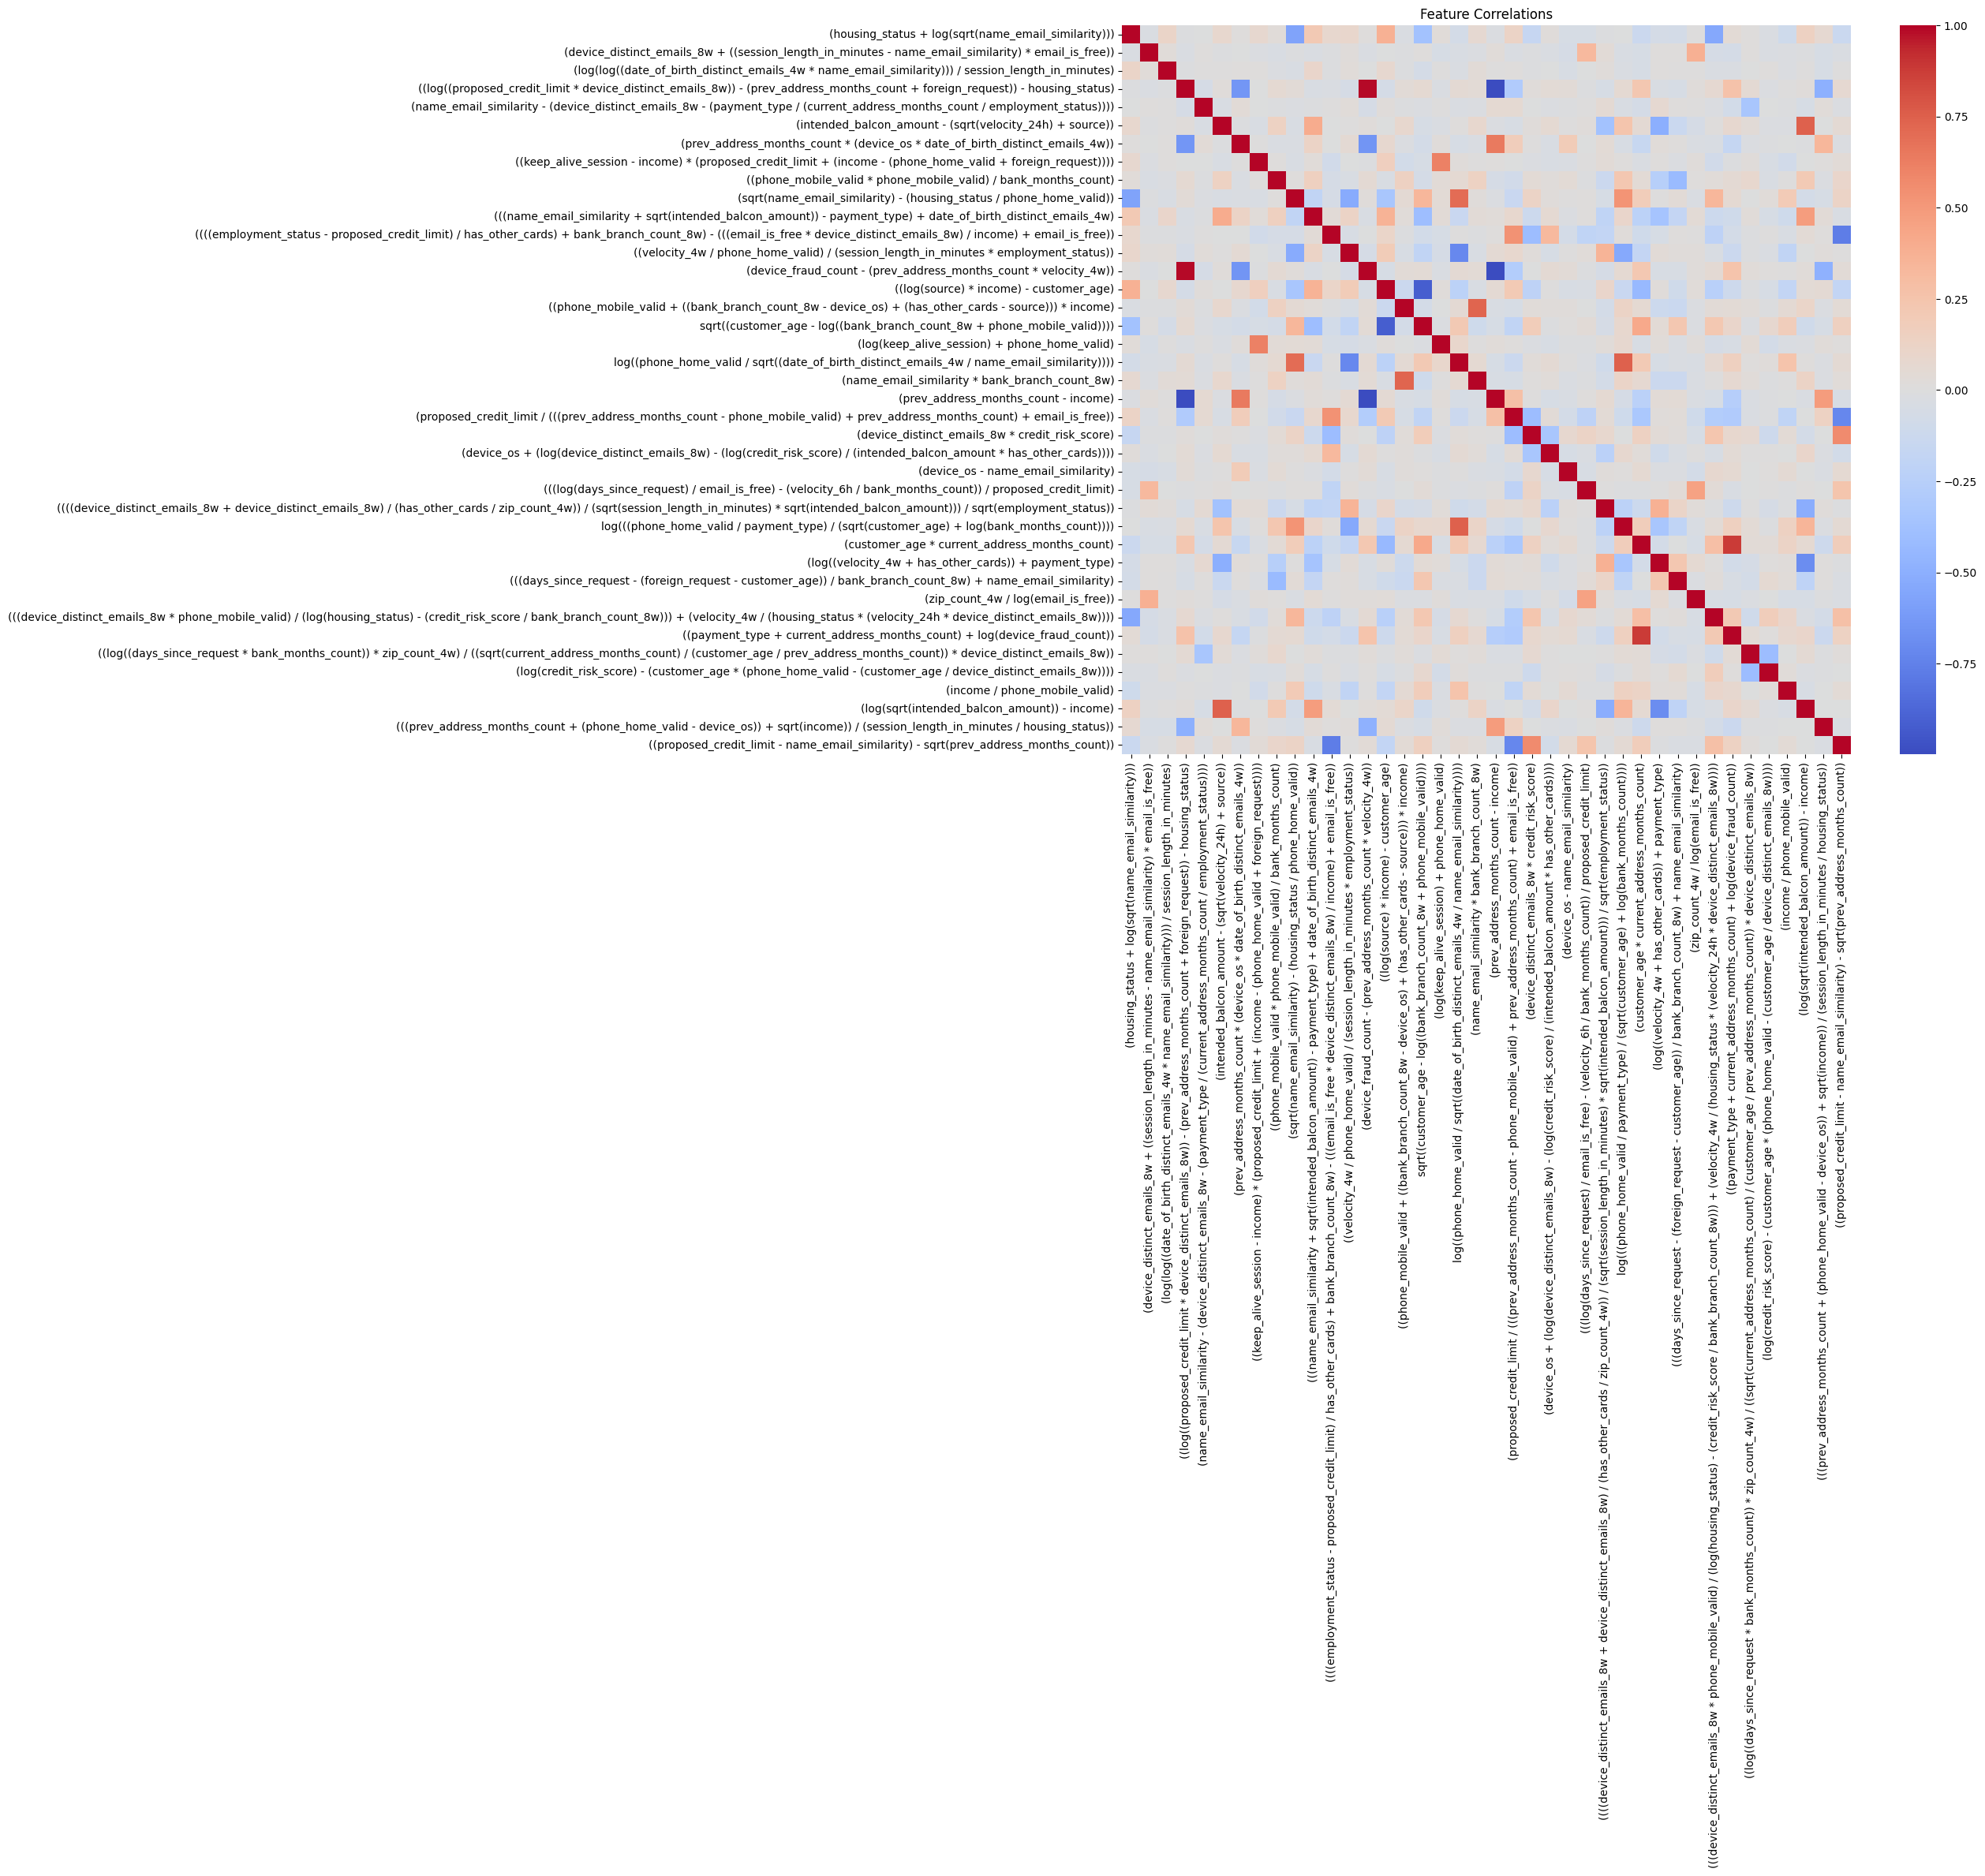

In [ ]:
#create a correlation map between archive features
correlation_matrix = ARCHIVE_T_DF_TEMP.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlations')
plt.tight_layout()
plt.show()


In [ ]:
original_cols = set(X_train.columns)

model_baseline = lgb.LGBMClassifier(
    n_estimators=350, max_depth=14, learning_rate=0.03, 
    num_leaves=17, boosting_type='gbdt', random_state=42, 
    n_jobs=-1, verbose=-1, 
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum()
)

model_baseline.fit(X_train, y_train, categorical_feature=categorical_indices)
original_probs = model_baseline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, original_probs)
target_fpr = target_fpr_value
original_tpr_at_fpr = 0.0

if np.any(fpr <= target_fpr):
    valid_indices = np.where(fpr <= target_fpr)[0]
    best_index = valid_indices[np.argmax(tpr[valid_indices])]
    original_tpr_at_fpr = tpr[best_index]

print(f"Baseline Model (Original Features Only)")
print(f"Test TPR at FPR {target_fpr}: {original_tpr_at_fpr}")

Baseline Model (Original Features Only)
Test TPR at FPR 0.05: 0.5403057678943711


In [ ]:
import pickle

with open("checkpoints/archive.pkl", "rb") as f:
    data = pickle.load(f)
    ARCHIVE_T_DF_TEMP = data['ARCHIVE_T_DF_TEMP']
    baseline_tpr_at_fpr = data['baseline_tpr_at_fpr']
    feature_expressions = data.get('feature_expressions', {})

print(f"Loaded archive: {ARCHIVE_T_DF_TEMP.shape}")

original_cols = set(X_train.columns)

X_combined = pd.concat([X_train, X_val, X_prune], ignore_index=True)
y_combined = pd.concat([y_train, y_val, y_prune], ignore_index=True)

X_combined_np = X_combined.to_numpy()
y_combined_np = y_combined.to_numpy()

X_train_augmented = pd.DataFrame(index=X_combined.index)
y_train_augmented = y_combined.copy()
X_test_augmented = pd.DataFrame(index=X_test.index)

for col in ARCHIVE_T_DF_TEMP.columns:
    if col in X_train.columns:
        X_train_augmented[col] = X_combined[col]
        X_test_augmented[col] = X_test[col]
    elif col in feature_expressions:
        train_feature = ARCHIVE_IND_DICT[col].get_phenotype().evaluate(X_combined_np)
        if train_feature.ndim == 0:
            train_feature = np.full(len(X_combined), train_feature)
        X_train_augmented[col] = train_feature

        test_feature = ARCHIVE_IND_DICT[col].get_phenotype().evaluate(X_test_np)
        if test_feature.ndim == 0:
            test_feature = np.full(len(X_test), test_feature)
        X_test_augmented[col] = test_feature

categorical_feature_names = [X_train.columns[i] for i in categorical_indices 
                            if i < len(X_train.columns)]
new_categorical_indices = [list(X_train_augmented.columns).index(name) 
                          for name in categorical_feature_names 
                          if name in X_train_augmented.columns]

model_aug = lgb.LGBMClassifier(
    n_estimators=350, max_depth=14, learning_rate=0.03, 
    num_leaves=17, boosting_type='gbdt', random_state=42, 
    n_jobs=-1, verbose=-1, 
    scale_pos_weight=(y_train_augmented==0).sum() / (y_train_augmented==1).sum()
)

model_aug.fit(X_train_augmented, y_train_augmented, 
             categorical_feature=new_categorical_indices if new_categorical_indices else None)

augmented_probs = model_aug.predict_proba(X_test_augmented)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, augmented_probs)
augmented_tpr_at_fpr = 0.0

if np.any(fpr <= target_fpr):
    valid_indices = np.where(fpr <= target_fpr)[0]
    best_index = valid_indices[np.argmax(tpr[valid_indices])]
    augmented_tpr_at_fpr = tpr[best_index]

print(f"Baseline TPR @ FPR {target_fpr}:  {original_tpr_at_fpr}")
print(f"Augmented TPR @ FPR {target_fpr}: {augmented_tpr_at_fpr}")
print(f"Improvement: {augmented_tpr_at_fpr - original_tpr_at_fpr}")

Loaded archive: (397039, 40)


NameError: name 'X_train' is not defined